# Моделирование геометрической вероятности

> Предисловие. Задача взята из олимпиады имени Уильяма Лоуэлла Патнэма – престижное ежегодное соревнование по математике для студентов бакалавриата в США и Канаде. Автор вдохновлен YouTube каналом 3Blue1Brown. Так как, сама условие задачи базируется на стеореометрических понятиях, возьмем ее упрощение и решим в двумерном пространстве. Источники:
> - https://habr.com/ru/articles/533196/
> - https://www.youtube.com/watch?v=S6_R5j8hzbY


### Формулировка и постановка задачи.

**Выберем 3 случайные точки на окружности. Какова вероятность, что центр окружности будет внутри треугольника, образованного этими точками?**

Для реализации данного примера надо генерировать точки **на** окружности, следовательно рандомно получать точки на окружности. Для этого выведем формулу для генерации точки $\mathcal{A}(x, y)$, находящейся в рандомном месте на окружности.\
Уравнение окружности: $(x - x_0)^2 + (y - y_0)^2 = R^2$, где $(x_0, y_0)$ – центр окружности\
ОТТ: $sin^2(\alpha) + cos^2(\alpha) = 1$\
\
$\begin{cases}
(x - x_0)^2 + (y - y_0)^2 = R^2,\\ 
sin^2(\alpha) + cos^2(\alpha) = 1 &\text{|} \cdot R^2
\end{cases}$
$\Rightarrow$
$\begin{cases}
(x - x_0)^2 + (y - y_0)^2 = R^2,\\ 
R^2\sin^2(\alpha) + cos^2(\alpha) = R^2
\end{cases}$
$\Rightarrow$
$\begin{cases}
(x - x_0)^2 + (y - y_0)^2 = R^2,\\ 
R^2\sin^2(\alpha) + R^2cos^2(\alpha) = R^2
\end{cases}$
$\Rightarrow$
$\Rightarrow$
$\begin{cases}
(x - x_0)^2 + (y - y_0)^2 = R^2,\\ 
(R\cdot\sin(\alpha))^2 + (R\cdot\cos^2(\alpha))^2 = R^2
\end{cases}$
$\Rightarrow$
$\begin{cases}
(x - x_0) = R\cdot\sin(\alpha),\\ 
(y - y_0)= R\cdot\cos(\alpha)
\end{cases}$
, где $0 \leq \alpha \leq 2\pi$


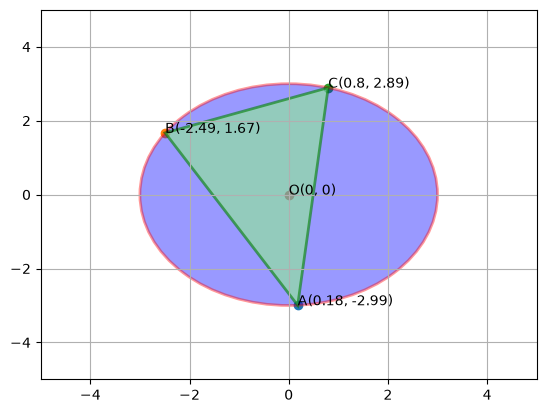

In [257]:
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Circle, Polygon
from random import randint, uniform

circle_radius = 3
circle_x0 = 0
circle_y0 = 0

def generate_random_alpha() -> float:
    return uniform(0, 2 * math.pi)

alpha = generate_random_alpha()

def generate_random_point(alpha: float) -> tuple[float, float]:
    x = circle_x0 + circle_radius * math.sin(alpha)
    y = circle_y0 + circle_radius * math.cos(alpha)
    return x, y

triangle_vertices = [generate_random_point(generate_random_alpha()) for _ in range(3)]
triangle_annotations = list('ABC')

fig, ax = plt.subplots()

circle = Circle(
    (circle_x0, circle_y0), circle_radius,
    linewidth=2,
    edgecolor='r',
    facecolor='blue',
    alpha=0.4
)

triangle = Polygon(
    triangle_vertices,
    linewidth=2,
    edgecolor='green',
    facecolor='lightgreen',
    alpha=0.6
)

for i, vertice in enumerate(triangle_vertices):
    x, y = vertice
    ax.scatter(*vertice)
    ax.annotate(f'{triangle_annotations[i]}({round(x, 2)}, {round(y, 2)})', vertice)

ax.scatter(circle_x0, circle_y0)
ax.annotate(f'O({circle_x0}, {circle_y0})', (circle_x0, circle_y0))

ax.add_patch(circle)
ax.add_patch(triangle)

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

plt.grid()
plt.show()

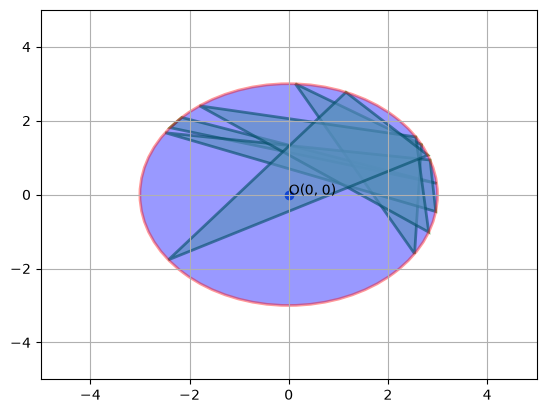

In [258]:
fig, ax = plt.subplots()

circle = Circle(
    (circle_x0, circle_y0), circle_radius,
    linewidth=2,
    edgecolor='r',
    facecolor='blue',
    alpha=0.4
)

for _ in range(5):
    triangle_vertices = [generate_random_point(generate_random_alpha()) for _ in range(3)]
    triangle_annotations = list('ABC')
    
    triangle = Polygon(
        triangle_vertices,
        linewidth=2,
        edgecolor='green',
        facecolor='lightgreen',
        alpha=0.6
    )

    ax.add_patch(triangle)

ax.scatter(circle_x0, circle_y0)
ax.annotate(f'O({circle_x0}, {circle_y0})', (circle_x0, circle_y0))

ax.add_patch(circle)

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

plt.grid()
plt.show()

Зафиксируем две точки, а одну будем менять

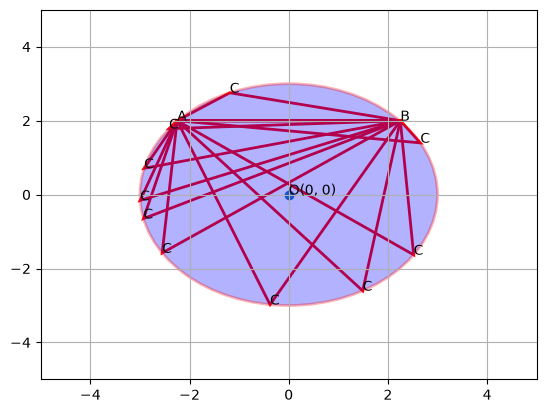

In [133]:
fig, ax = plt.subplots()

circle = Circle(
    (circle_x0, circle_y0), circle_radius,
    linewidth=2,
    edgecolor='r',
    facecolor='blue',
    alpha=0.3
)

for _ in range(10):
    point = generate_random_point(generate_random_alpha())
    triangle_vertices = [
        (-2.25, 2),
        (2.25, 2),
        point,
    ]
    
    triangle = Polygon(
        triangle_vertices,
        linewidth=2,
        edgecolor='red',
        facecolor='None',
        alpha=1
    )

    ax.add_patch(triangle)
    ax.annotate(f'C', point)

ax.scatter(circle_x0, circle_y0)
ax.annotate(f'O({circle_x0}, {circle_y0})', (circle_x0, circle_y0))


ax.annotate(f'A', (-2.25, 2))
ax.annotate(f'B', (2.25, 2))

ax.add_patch(circle)

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

plt.grid()
plt.show()

Заметим, что после фиксации точек $A(-2.25, 2)$ и $B(2.25, 2)$, с имперически взятыми координатами, можно заметить, что центр окружности попадает в треугольник при условии, что точка $C$ с рандомными координатами лежит на противолежащей дуге к $AB$

Точка $C$ с равной вероятностью может оказаться в **любой** точке на окружности. Но нам надо узнать вероятность попадания точки $C$ на **нужную** дугу:

Вероятность события $X$ – точка $C$ попадет на нужную дугу: $P(X) = \frac{\text{Длина дуги}}{\text{Длина окружности}}$

Если сделать вывод, то по сути все зависит от расположения точек $A$ и $B$. Если $\angle{ABO} = 90^{\circ} \Rightarrow P(X) = \frac{90^{\circ}}{360^{\circ}} = \frac{1}{4}$. 

Заметим, что если располагать точки дальше друг от друга, тогда длина дуги $AB \rightarrow 180^{\circ} \Rightarrow P(X) \rightarrow \frac{1}{2}$, а если расположить их ближе друг к другу, то $AB \rightarrow 0^{\circ} \Rightarrow P(X) \rightarrow 0$

Расположение точек $A$, $B$, $C$ – события равновероятные

Сделаем полную симуляцию:

In [141]:
def triangle_area(
    a: tuple[float, float],
    b: tuple[float, float],
    c: tuple[float, float]
):
    x1, y1 = a
    x2, y2 = b
    x3, y3 = c

    return 0.5 * abs(
        (x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)
    )

def circle_area(circle_radius: float):
    return math.pi * (circle_radius ** 2)

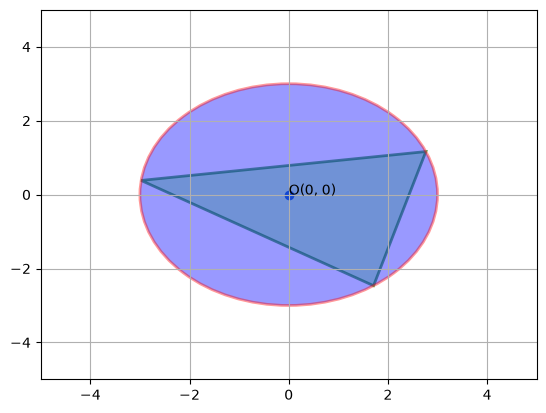

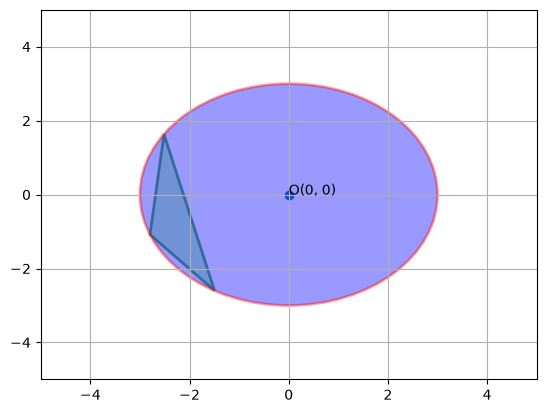

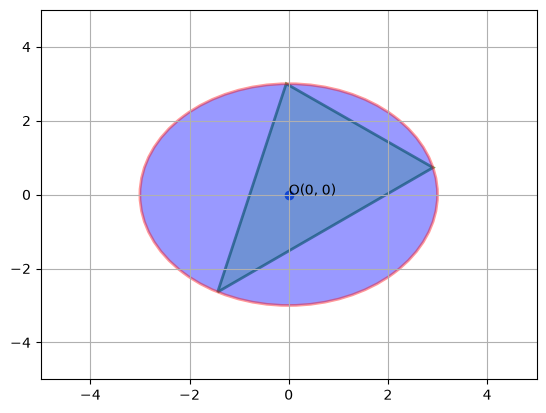

In [259]:
COUNT_TRIES = 3

probability_counter = 0

for _ in range(COUNT_TRIES):
    fig, ax = plt.subplots()

    circle = Circle(
        (circle_x0, circle_y0), circle_radius,
        linewidth=2,
        edgecolor='r',
        facecolor='blue',
        alpha=0.4
    )
    triangle_vertices = [generate_random_point(generate_random_alpha()) for _ in range(3)]
    triangle_annotations = list('ABC')
    
    triangle = Polygon(
        triangle_vertices,
        linewidth=2,
        edgecolor='green',
        facecolor='lightgreen',
        alpha=0.6
    )

    probability = triangle_area(*triangle_vertices) / circle_area(circle_radius)

    ax.add_patch(triangle)

    ax.scatter(circle_x0, circle_y0)
    ax.annotate(f'O({circle_x0}, {circle_y0})', (circle_x0, circle_y0))
    
    ax.add_patch(circle)
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    
    plt.grid()
    plt.show()

In [240]:
def point_in_triangle(point, triangle_vertices):
    a, b, c = triangle_vertices
    px, py = point

    def cross(a, b, p):
        return (
            (b[0] - a[0]) * (p[1] - a[1])
            - (b[1] - a[1]) * (p[0] - a[0])
        )

    s1 = cross(a, b, point)
    s2 = cross(b, c, point)
    s3 = cross(c, a, point)

    return (
        (s1 >= 0 and s2 >= 0 and s3 >= 0)
        or
        (s1 <= 0 and s2 <= 0 and s3 <= 0)
    )

In [252]:
def simulate(count_tries: int) -> float:
    favorable_counter = 0

    fig, ax = plt.subplots()

    circle = Circle(
        (circle_x0, circle_y0),
        circle_radius,
        linewidth=2,
        edgecolor='r',
        facecolor='blue',
        alpha=0.4
    )

    ax.add_patch(circle)

    ax.scatter(circle_x0, circle_y0)
    ax.annotate(
        f'O({circle_x0}, {circle_y0})',
        (circle_x0, circle_y0)
    )

    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid()

    for _ in range(count_tries):
        triangle_vertices = [
            generate_random_point(generate_random_alpha())
            for _ in range(3)
        ]

        if point_in_triangle(
            (circle_x0, circle_y0),
            triangle_vertices
        ):
            favorable_counter += 1

        triangle = Polygon(
            triangle_vertices,
            linewidth=1,
            edgecolor='green',
            facecolor='lightgreen',
            alpha=0.1
        )

        ax.add_patch(triangle)

    probability = favorable_counter / count_tries

    ax.set_title(
        f'P ≈ {probability:.4f}\n'
        f'Благоприятных: {favorable_counter}/{count_tries}'
    )

    plt.show()

    return probability

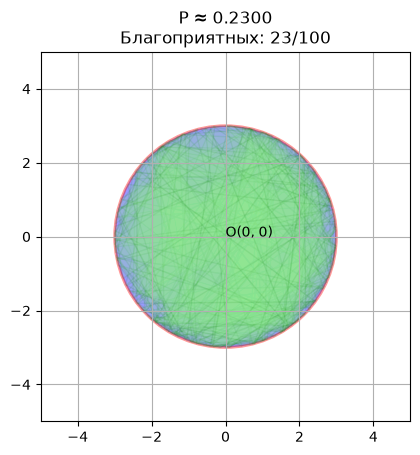

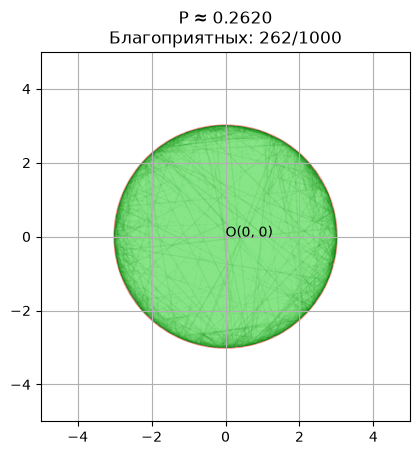

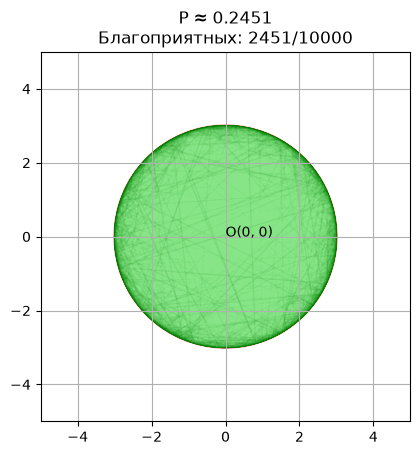

0.2451

In [256]:
simulate(100)
simulate(1000)
simulate(10000)

Ответ: $P(X) = \frac{1}{4}$